In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import pickle
import umap
import hdbscan


c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
base = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")      # generic

In [110]:
df = pd.read_excel('../input_data/updated_aoi_vector_hdbscan_input.xlsx')

In [7]:
rows_of_users_1= []
rows_of_users_2 = []
rows_of_users_3= []
for i,j in df.iterrows():
    sentenc1= f"{j['aoi_1']}, {j['aoi_2']}, {j['aoi_3']}, {j['aoi_4']}, {j['aoi_5']} — areas of interest for a {j['Job_Seniority']} in {j['Job_Function']} from the {j['Parent Industry']} industry."
    sentenc2  = f"An {j['Job_Seniority']} in {j['Job_Function']} from the {j['Parent Industry']} industry, working in a company with a turnover of {j['Turnover_Range']} and {j['Employees_Range']} employees. Their key areas of interest include {j['aoi_1']}, {j['aoi_2']}, {j['aoi_3']}, {j['aoi_4']}, and {j['aoi_5']}."
    sentenc3 = f"An {j['Job_Seniority']} in {j['Job_Function']} from the {j['Parent Industry']} industry. Their key areas of interest include {j['aoi_1']}, {j['aoi_2']}, {j['aoi_3']}, {j['aoi_4']}, and {j['aoi_5']}."
    rows_of_users_1.append(sentenc1)
    rows_of_users_2.append(sentenc2)
    rows_of_users_3.append(sentenc3)

In [13]:
print(rows_of_users_1[0])

AI in Marketing,  Marketing Automation,  Customer Engagement,  Human-AI Interaction,  Collaboration & AI-Augmentation — areas of interest for a Executive in General Management from the Finance industry.


In [15]:
embedding_front= base.encode(rows_of_users_1, normalize_embeddings=True)
embedding_with_turn = base.encode(rows_of_users_2, normalize_embeddings=True)
embedding_back = base.encode(rows_of_users_3, normalize_embeddings=True)

In [25]:
len(embedding_front)
with open('../vector/embeddings_with_turnover.pkl', 'wb') as f:
    pickle.dump(embedding_with_turn, f)

In [5]:
with open("../vector/embeddings_back.pkl", "rb") as f:
    embeddings_back = pickle.load(f)
with open("../vector/embeddings_front.pkl", "rb") as f:
    embeddings_front = pickle.load(f)
with open("../vector/embeddings_with_turnover.pkl", "rb") as f:
    embeddings_with_turn = pickle.load(f)

In [16]:
sim_matrix = cosine_similarity(embeddings_back)
np.fill_diagonal(sim_matrix, 0)
print("Max similarity:", sim_matrix.max())
print("Mean similarity:", sim_matrix.mean())

Max similarity: 1.0000008
Mean similarity: 0.74154985


In [4]:

X_std1 = StandardScaler().fit_transform(embeddings_back)       
X_2d1  = umap.UMAP(n_components=2).fit_transform(X_std1)  
X_std2 = StandardScaler().fit_transform(embeddings_front)       
X_2d2  = umap.UMAP(n_components=2).fit_transform(X_std2)  
X_std3 = StandardScaler().fit_transform(embeddings_with_turn)       
X_2d3  = umap.UMAP(n_components=2,random_state=42).fit_transform(X_std3)  

NameError: name 'embeddings_back' is not defined

In [10]:

clusterer = hdbscan.HDBSCAN(min_cluster_size=15,min_samples=25,metric="l1")
labels = clusterer.fit_predict(X_std2)
df["Front_cluster_scaled"] = labels
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric="euclidean")
labels = clusterer.fit_predict(X_2d2)
df["Front_cluster_2d"] = labels
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric="euclidean")
labels = clusterer.fit_predict(embedding_front)
df["Front_cluster_embedded"] = labels

NameError: name 'hdbscan' is not defined

In [91]:
# clusterer = hdbscan.HDBSCAN(min_cluster_size=15,min_samples=25,metric="l1")
# labels = clusterer.fit_predict(X_std3)
# df["cluster_WT_Tl1"] = labels
# X_std3 = StandardScaler().fit_transform(embeddings_with_turn)       
# X_2d3  = umap.UMAP(n_components=2).fit_transform(X_std3)  
# clusterer = hdbscan.HDBSCAN()
# labels = clusterer.fit_predict(X_2d3)
# df["cluster_N"] = labels
clusterer = hdbscan.HDBSCAN(min_samples=25,metric="l2")
labels = clusterer.fit_predict(X_2d3)
# df["cluster_WT_l2_2d"] = labels
# clusterer = hdbscan.HDBSCAN(min_cluster_size=15,min_samples=25,metric="l1")
# labels = clusterer.fit_predict(X_2d3)
# df["cluster_WT_l1_2d"] = labels

c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [105]:
clusterer = hdbscan.HDBSCAN( metric="l1")#minkowski
labels = clusterer.fit_predict(X_std2)

c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


21
[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725), (0.8666666666666667, 0.5176470588235295, 0.3215686274509804), (0.3333333333333333, 0.6588235294117647, 0.40784313725490196), (0.7686274509803922, 0.3058823529411765, 0.3215686274509804), (0.5058823529411764, 0.4470588235294118, 0.7019607843137254), (0.5764705882352941, 0.47058823529411764, 0.3764705882352941), (0.8549019607843137, 0.5450980392156862, 0.7647058823529411), (0.5490196078431373, 0.5490196078431373, 0.5490196078431373), (0.8, 0.7254901960784313, 0.4549019607843137), (0.39215686274509803, 0.7098039215686275, 0.803921568627451), (0.2980392156862745, 0.4470588235294118, 0.6901960784313725), (0.8666666666666667, 0.5176470588235295, 0.3215686274509804), (0.3333333333333333, 0.6588235294117647, 0.40784313725490196), (0.7686274509803922, 0.3058823529411765, 0.3215686274509804), (0.5058823529411764, 0.4470588235294118, 0.7019607843137254), (0.5764705882352941, 0.47058823529411764, 0.3764705882352941), (0.854901960784

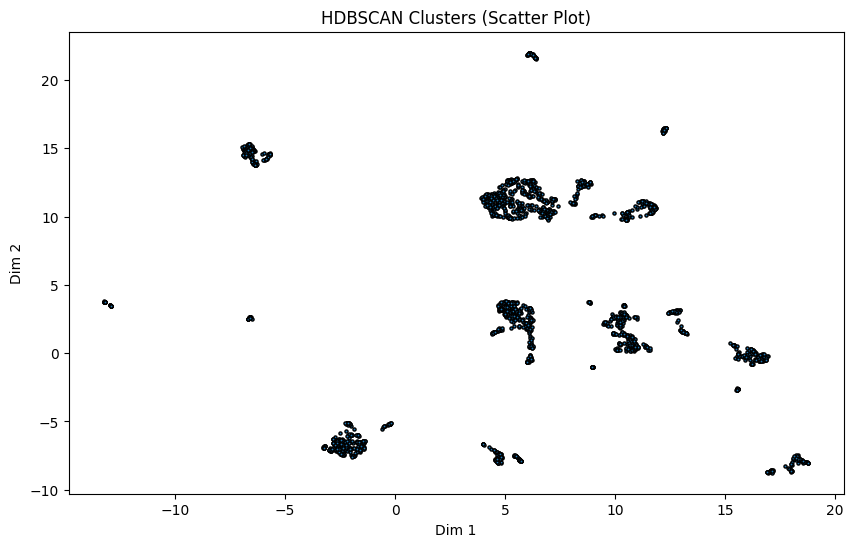

In [92]:

import matplotlib.pyplot as plt
import seaborn as sns
# aa=embeddings_with_turn.toarray()
palette = sns.color_palette('deep', np.unique(labels).max() + 1)
colors = [palette[l] if l >= 0 else (0.5, 0.5, 0.5) for l in labels]
print(len(np.unique(labels)))
print(palette)
print((colors))
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_2d3[:, 0], X_2d3[:, 1],s=5,edgecolors='k')
plt.title('HDBSCAN Clusters (Scatter Plot)')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.show()



In [1]:


# Your existing code (assuming X_2d3 and labels are defined)
# palette = sns.color_palette('deep', np.unique(labels).max() + 1)
# colors = [palette[l] if l >= 0 else (0.5, 0.5, 0.5) for l in labels]

# Step 1: Get unique cluster labels (exclude noise if desired)
unique_clusters = np.unique(labels[labels >= 0])  # e.g., [0, 1, 2]

# Step 2: Create legend patches (colored boxes with labels)
legend_patches = []
for i, cluster in enumerate(unique_clusters):
    color = palette[cluster]  # Get the color for this cluster
    patch = mpatches.Patch(color=color, label=f'Cluster {cluster}')  # Create box with label
    legend_patches.append(patch)

# Add noise to legend (optional)
legend_patches.append(mpatches.Patch(color=(0.5, 0.5, 0.5), label='Noise (-1)'))

# Step 3: Plot with legend
plt.figure(figsize=(10, 6))
plt.scatter(X_2d3[:, 0], X_2d3[:, 1], s=100, c=colors, edgecolors='k')
plt.title('HDBSCAN Clusters (Scatter Plot with Legend)')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5))  # Add the legend here
plt.show()
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplcursors  # pip install mplcursors

# Your data and clustering (from previous steps)
# Assume X_2d3 is your 2D points, labels are cluster numbers
# Example placeholders (replace with yours)


# Colors setup (your code)
palette = sns.color_palette('deep', np.unique(labels).max() + 1)
colors = [palette[l] if l >= 0 else (0.5, 0.5, 0.5) for l in labels]

# Plot (your code)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d3[:, 0], X_2d3[:, 1], s=100, c=colors, edgecolors='k')
plt.title('HDBSCAN Clusters (Scatter Plot)')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')

# Add hover with cluster number
cursor = mplcursors.cursor(scatter, hover=True)
@cursor.connect('add')
def _(selection):
    i = selection.index  # Get hovered point's index
    x, y = X_2d3[i]  # Get coordinates
    cluster = labels[i]  # Get cluster number
    selection.annotation.set(text=f'Cluster: {cluster}\nX: {x:.2f}\nY: {y:.2f}',
                             bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.show()


NameError: name 'np' is not defined

In [112]:
df.to_excel("./outputn.xlsx")

In [22]:
X_2d3

array([[ 3.385631 , -9.226128 ],
       [16.820305 ,  2.4361553],
       [ 2.1612475, -8.199673 ],
       ...,
       [ 8.052767 , 10.268132 ],
       [-2.5358045, -7.329759 ],
       [18.818598 , -6.808966 ]], shape=(2436, 2), dtype=float32)

In [138]:
top_industries = (
    df.groupby(['cluster_N','Parent Industry','Job_Seniority','Job_Function'])
      .size()
      .reset_index(name='count')
      .sort_values(['cluster_N', 'count'], ascending=[True, False])
      .groupby('cluster_N')
      .head(2)
)

In [140]:
top_industries.to_excel("./test_n.xlsx")

In [53]:
top_industries

,cluster_2d,count
0,-1,182
1,0,26
2,1,20
3,2,27
4,3,27
5,4,25
6,5,238
7,6,37
8,7,51
9,8,22


In [ ]:
df.to_excel("../output/Default.xlsx")

In [2]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter
import os
from pathlib import Path

# Step 1: Define input files
input_files = [
    '../New folder/kmeans.xlsx'
    # Add more file paths as needed
]

# Step 2: Read and process all Excel files
all_cluster_data = {}  # Dictionary to store data from each file

for file_path in input_files:
    if os.path.exists(file_path):
        df = pd.read_excel(file_path)
        cluster_cols = [col for col in df.columns if col.startswith("cluster")]
        
        file_name = Path(file_path).stem  # Get filename without extension
        all_cluster_data[file_name] = {}
        
        # Process each cluster column for this file
        for col_name in cluster_cols:
            labels = df[col_name]
            cluster_sizes = labels.value_counts().sort_index()
            cluster_labels = ['Noise (-1)' if x == -1 else x for x in cluster_sizes.index]
            all_cluster_data[file_name][col_name] = {
                'labels': cluster_labels,
                'counts': cluster_sizes.values
            }
        
        print(f"Processed {file_path}: Found {len(cluster_cols)} cluster columns")
    else:
        print(f"Warning: File {file_path} not found")

# Step 3: Prepare output Excel file
output_excel = "../output/cluster_sizes_km.xlsx"

# Step 4: Create Excel file with empty sheet
with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    pd.DataFrame().to_excel(writer, sheet_name='Clusters', index=False)

# Step 5: Open workbook and set active sheet
wb = load_workbook(output_excel)
ws = wb['Clusters']

# Step 6: Write data side by side
current_col = 1  # Starting column

for file_name, file_data in all_cluster_data.items():
    if not file_data:  # Skip if no cluster columns found
        continue
        
    # Write file name as header spanning all cluster columns for this file
    num_cluster_cols = len(file_data)
    if num_cluster_cols > 0:
        ws.cell(row=1, column=current_col, value=file_name)
        ws.cell(row=1, column=current_col).font = Font(bold=True, size=14)
        ws.cell(row=1, column=current_col).alignment = Alignment(horizontal='center')
        
        # Merge cells across all cluster columns for this file (each cluster takes 2 columns)
        end_col = current_col + (num_cluster_cols * 2) - 1
        ws.merge_cells(start_row=1, start_column=current_col, end_row=1, end_column=end_col)
        
        # Process each cluster column for this file
        cluster_col_start = current_col
        for cluster_name, cluster_info in file_data.items():
            # Write cluster column name as header
            ws.cell(row=2, column=cluster_col_start, value=cluster_name)
            ws.cell(row=2, column=cluster_col_start).font = Font(bold=True)
            ws.cell(row=2, column=cluster_col_start).alignment = Alignment(horizontal='center')
            ws.merge_cells(start_row=2, start_column=cluster_col_start, 
                          end_row=2, end_column=cluster_col_start + 1)
            
            # Write table headers
            ws.cell(row=3, column=cluster_col_start, value='Cluster Label').font = Font(bold=True)
            ws.cell(row=3, column=cluster_col_start + 1, value='Number of Points').font = Font(bold=True)
            
            # Write cluster data
            for i, (label, count) in enumerate(zip(cluster_info['labels'], cluster_info['counts']), start=4):
                ws.cell(row=i, column=cluster_col_start, value=label)
                ws.cell(row=i, column=cluster_col_start + 1, value=count)
            
            # Move to next cluster column (2 columns per cluster)
            cluster_col_start += 2
        
        # Update current_col for next file (add some spacing)
        current_col = end_col + 2  # 2 columns spacing between files

# Step 7: Adjust column widths for readability
for col_idx in range(1, current_col):
    col_letter = get_column_letter(col_idx)
    try:
        max_length = max(len(str(cell.value)) for cell in ws[col_letter] if cell.value)
        ws.column_dimensions[col_letter].width = min(max_length + 2, 20)  # Cap at 20 for readability
    except:
        ws.column_dimensions[col_letter].width = 12  # Default width

# Step 8: Save the updated Excel file
wb.save(output_excel)
print(f"All cluster size summaries from multiple files written side by side to '{output_excel}'.")


Processed ../New folder/kmeans.xlsx: Found 1 cluster columns
All cluster size summaries from multiple files written side by side to '../output/cluster_sizes_km.xlsx'.
